In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [17]:
data = pd.read_csv("noisy_curvefit_data.csv")

In [18]:
print(data.shape)

(100, 6)


In [19]:
data.head() #first 5 entries


,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
0,-1.000000,11.624419,8.296963,12.201067,7.811725,3.155566
1,-0.929293,10.377466,9.674440,12.198084,8.275006,7.518855
2,-0.858586,10.585100,9.251983,13.186565,12.926586,9.963630
3,-0.787879,10.913928,7.786344,12.552304,11.832379,9.625801
4,-0.717172,8.640287,8.551869,4.741432,8.790834,6.624113


In [20]:
data.tail() # last 5 entries

,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
95,5.717172,-1.411918,0.822231,-2.027132,-1.825106,2.746147
96,5.787879,0.344879,-1.718956,2.747559,-6.803779,-5.137472
97,5.858586,0.307133,0.353528,0.967976,5.461567,-0.905616
98,5.929293,0.048657,0.159961,2.482130,-0.414616,-4.334548
99,6.000000,-0.193438,-2.244792,1.930035,4.992414,-6.872850


In [21]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   x          100 non-null    float64
 1   y_noise_1  100 non-null    float64
 2   y_noise_2  100 non-null    float64
 3   y_noise_3  100 non-null    float64
 4   y_noise_4  100 non-null    float64
 5   y_noise_5  100 non-null    float64
dtypes: float64(6)
memory usage: 4.8 KB
None


<function matplotlib.pyplot.show(close=None, block=None)>

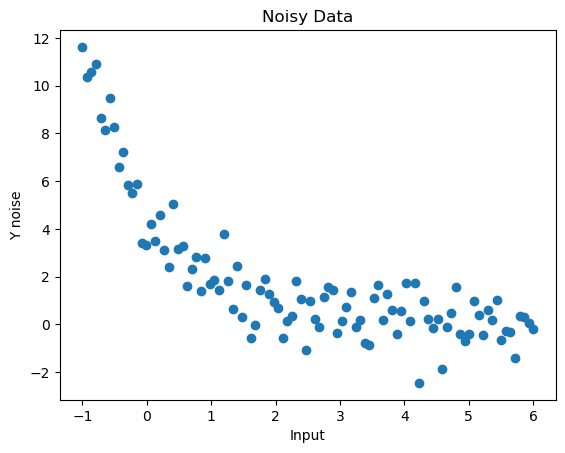

In [22]:
#creating a scatter plot of the data frame
x_data = data['x']
y_data = data['y_noise_1']
plt.scatter(x_data, y_data, label='x vs y noise')
plt.xlabel('Input')
plt.ylabel('Y noise')
plt.title("Noisy Data")
plt.show

In [24]:
#defining a curve fit function A * e^-kx

def model(x, A, k):
    return A * np.exp(-k * x)

p0 = [1, 1] #initial guess
popt, pcov = curve_fit(model, x_data, y_data, p0=p0) #curve fitting with optimal parameters
A_fit, k_fit = popt 
print("--- Fitted Model Equation ---")
print(f"Fit: y = {A_fit:.2f} * e^({-k_fit:.2f} * x)")

--- Fitted Model Equation ---
Fit: y = 4.71 * e^(-0.92 * x)


In [25]:
residuals = y_data - model(x_data, A_fit, k_fit)

#equation for chi^2
chi2 = np.sum(residuals**2)

# Calculate degrees of freedom (n - p)
# n = number of data points
# p = number of parameters
dof = len(x_data) - len(popt)

# Calculate reduced chi-squared
chi2_reduced = chi2 / dof

print("\n--- Goodness of Fit ---")
print(f"Reduced Chi-Squared: {chi2_reduced:.2f}")


--- Goodness of Fit ---
Reduced Chi-Squared: 0.79


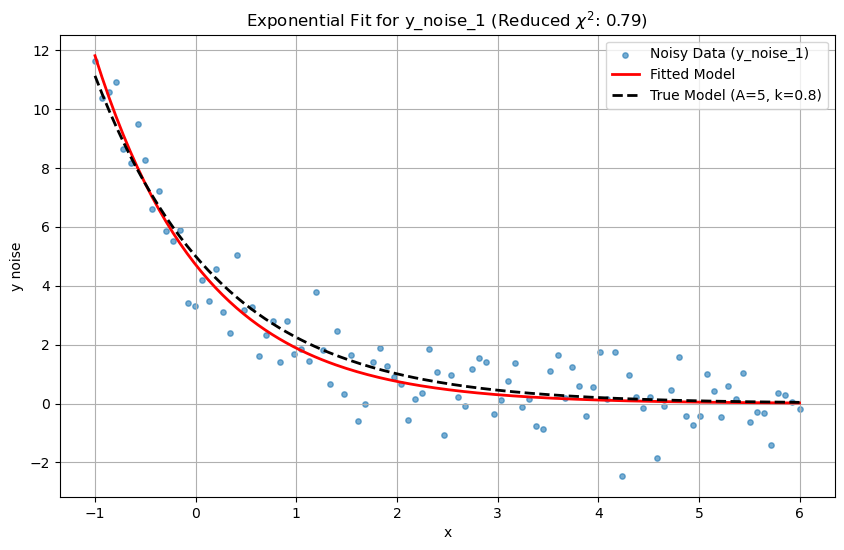

In [28]:
# making a smooth set of x-values and y-values for the fitted line
x_fit = np.linspace(min(x_data), max(x_data), 200)
y_fit = model(x_fit, A_fit, k_fit)

# Calculate the y-values for the "true" model
y_true = model(x_fit, 5, 0.8)

plt.figure(figsize=(10, 6))

# scatter: noisy data
plt.scatter(x_data, y_data, label='Noisy Data (y_noise_1)', alpha=0.6, s=15)

# red line: fitted model
plt.plot(x_fit, y_fit, label='Fitted Model', color='red', linewidth=2)

# black dotted line: true model
plt.plot(x_fit, y_true, label='True Model (A=5, k=0.8)', color='black', linestyle='--', linewidth=2)

plt.title(f'Exponential Fit for y_noise_1 (Reduced $\chi^2$: {chi2_reduced:.2f})')
plt.xlabel('x')
plt.ylabel('y noise')
plt.legend()
plt.grid(True)
plt.show()

In [29]:
def fit_model(x, y):
    def model(x, A, k):
        return A * np.exp(-k * x)
    p0 = [1, 1]
    popt, pcov = curve_fit(model, df["x"], y, p0=p0)
    A_fit, k_fit = popt
    residuals = y - model(df["x"], A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(df["x"]) - len(popt)
    chi2_reduced = chi2 / dof
    return A_fit, k_fit, chi2_reduced

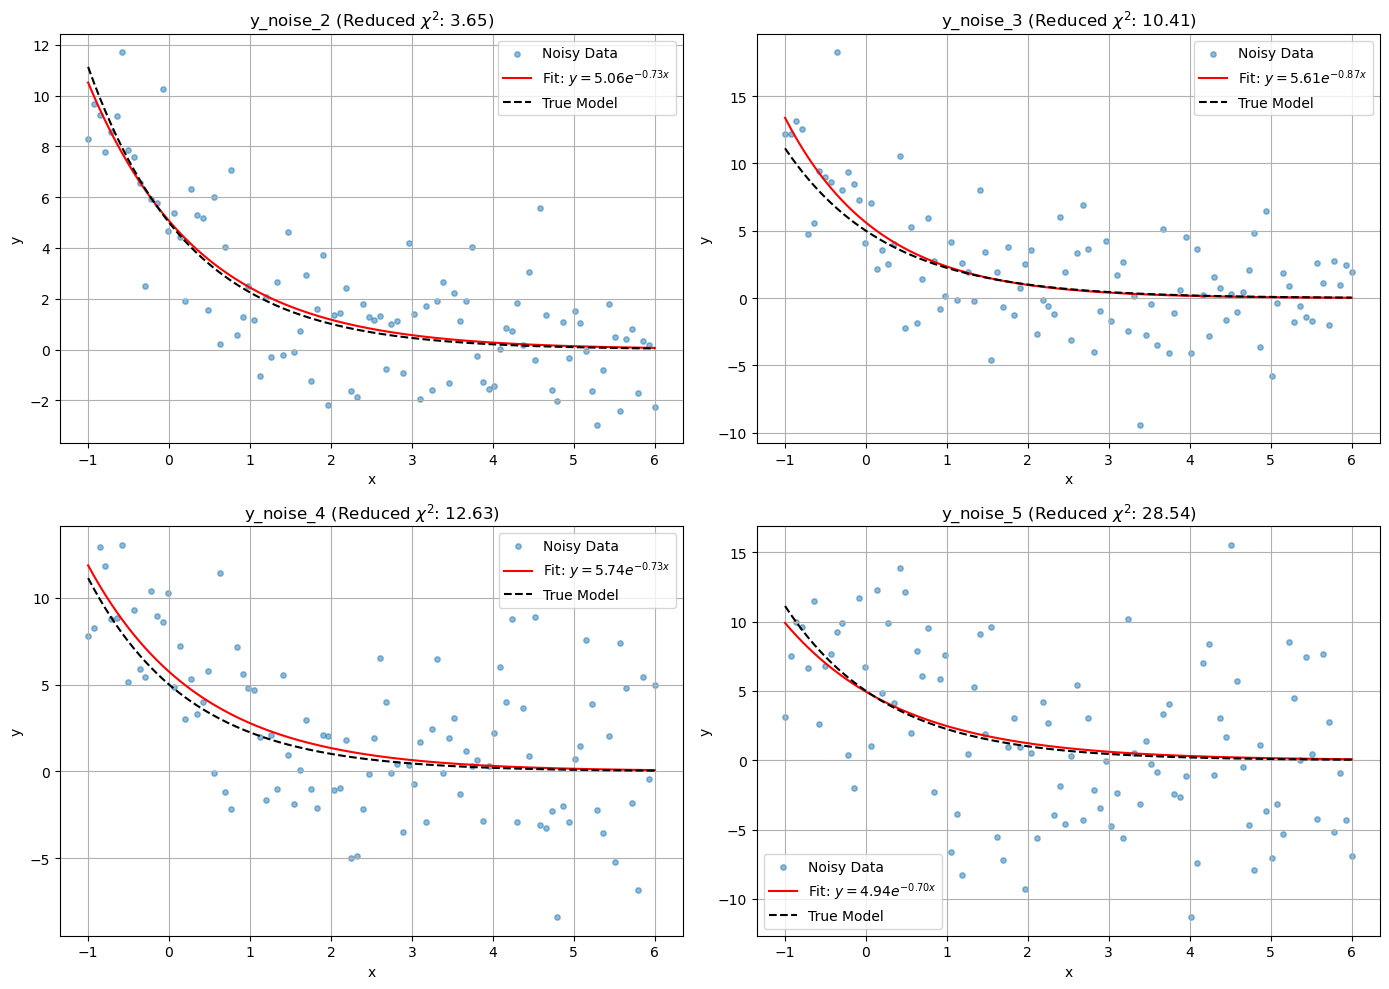

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
y_cols = ['y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5']

# Loops through the 4 columns and plot
for i, ax in enumerate(axes):
    y_col = y_cols[i]
    x_data = df['x']
    y_data = df[y_col]
    
    A_fit, k_fit, chi2_reduced = fit_model(x_data, y_data)
    
    x_plot = np.linspace(x_data.min(), x_data.max(), 200)
    y_plot_fit = model(x_plot, A_fit, k_fit)
    y_plot_true = model(x_plot, 5, 0.8) 
    
    ax.scatter(x_data, y_data, label='Noisy Data', alpha=0.5, s=15)
    ax.plot(x_plot, y_plot_fit, color='red', label=f'Fit: $y={A_fit:.2f}e^{{-{k_fit:.2f}x}}$')
    ax.plot(x_plot, y_plot_true, color='black', linestyle='--', label='True Model')
    
    # Formatting
    ax.set_title(f'{y_col} (Reduced $\chi^2$: {chi2_reduced:.2f})')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [36]:
#As the noise level increases the fit strays farther away from the true model
#Chi^2 is proportional to the amount of noise. Chi^2 measures the effectiveness of a curve fit, since more noise makes the fit worse, the chi squared increases with it

In [43]:
A_fits = [4.71, 5.06, 5.61, 5.74, 4.94]
k_fits = [0.92, 0.73, 0.87, 0.73, 0.70]
chi2_list = [0.79, 3.65, 10.41, 12.63, 28.54]
df2 = pd.DataFrame()
df2["Noise Level"] = [1, 2, 3, 4, 5]
df2["A fit"] = A_fits
df2["k fit"] = k_fits
df2["Reduced chi-squared"] = chi2_list

In [46]:
df2.to_csv("noisy_parameters.csv", index=False)

In [44]:
print(df2.head())

   Noise Level  A fit  k fit  Reduced chi-squared
0            1   4.71   0.92                 0.79
1            2   5.06   0.73                 3.65
2            3   5.61   0.87                10.41
3            4   5.74   0.73                12.63
4            5   4.94   0.70                28.54
